In [166]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import scipy as sp
import time
import scipy.stats as stats
from pathlib import Path
import numpy as np
import matplotlib.patches as mpatches
sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')



In [167]:
repo_folder = Path("../..")
gp_folder = repo_folder / 'data/1_growth_phenotyping'
figure_folder = repo_folder / "Figures" / "1_growth_phenotyping"


res_df = pd.read_csv(gp_folder / 'fitted_growth_parameters.csv', index_col=0)
binary_growth = pd.read_csv(gp_folder / 'growth_no_growth.csv', index_col = 0)
binary_growth.index = binary_growth.index.str.replace('L-', '').str.replace('D-','').str.capitalize()
binary_growth_dict = binary_growth.to_dict()

In [168]:
res_df['Carbon source'] = res_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

In [169]:
cs_class_df = pd.read_csv(gp_folder / 'selected_carbon_sources.csv')
cs_class_df.rename(columns={'Metabolite name': 'Carbon source'}, inplace=True)
cs_class_df['Carbon source'] = cs_class_df['Carbon source'].str.replace('L-', '').str.replace('D-','').str.capitalize()

cs_class_df.replace({'Metabolite class': {'Alcohol': 'Other', 'Nucleoside': 'Other', 'Simple sugar':'Sugar'}}, inplace=True)
cs_to_class = cs_class_df.set_index('Carbon source').to_dict()['Metabolite class']

# Make heatmaps

In [170]:
res_df = res_df.loc[res_df['Carbon source'] != 'No cs']

## Yield

In [171]:
yield_matrix = res_df[['Carbon source', 'Yield', 'Species']].pivot(index = 'Carbon source', columns='Species', values='Yield')


In [172]:
# Get the first four colors from the 'tab10' colormap
tab10_colors = [plt.cm.tab10.colors[i] for i in [4,5,6,8]]

# Create a mapping from classes to colors
unique_classes = sorted([x for x in list(set(cs_to_class.values())) if isinstance(x, str)]) # Get unique classes from cs_to_class
# Move 'Other'to the end
unique_classes.append(unique_classes.pop(unique_classes.index('Other')))

class_to_color = {cls: tab10_colors[i] for i, cls in enumerate(unique_classes)}

# Map the classes in `cs_to_class` to colors
row_colors = yield_matrix.index.map(cs_to_class).map(class_to_color)


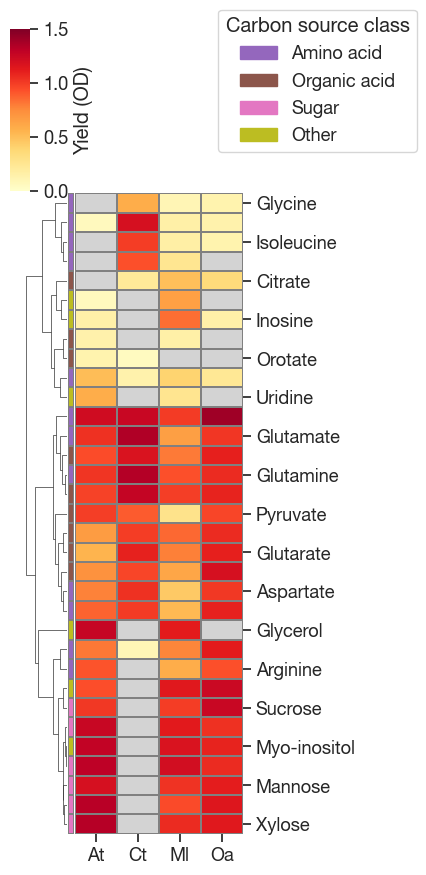

In [173]:
cmap = plt.colormaps.get_cmap('YlOrRd')
cmap.set_bad("lightgray")

mask = np.zeros(yield_matrix.shape, dtype=bool)
for i, c in enumerate(yield_matrix.index):
    for j, s in enumerate(yield_matrix.columns):
        mask[i,j] = not binary_growth_dict[s][c]
g = sns.clustermap(yield_matrix, vmin = 0, vmax = 1.5, cmap = cmap, mask = mask,figsize=(4,9), dendrogram_ratio=0.2, cbar_kws={'label': 'Yield (OD)'}, 
               row_colors=row_colors,
               col_cluster=False,
               linewidths=0.05, linecolor='gray')

# Create legend handles
handles = [
    mpatches.Patch(color=color, label=cls)
    for cls, color in class_to_color.items()
]

# Add legend to the clustermap
g.ax_heatmap.legend(
    handles=handles,
    title="Carbon source class",
    loc="lower left",
    bbox_to_anchor=(0.8, 1.05)
)

g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
fn_fig = figure_folder / 'clustermap_yield.pdf'

plt.savefig(fn_fig)

In [174]:
species = list(res_df.Species.unique())
species.sort()
carbon_sources = list(res_df['Carbon source'].unique())
carbon_sources.sort()
# carbon_sources.append(carbon_sources.pop(carbon_sources.index('No CS')))
carbon_sources = [x for x in carbon_sources if x != 'No cs']

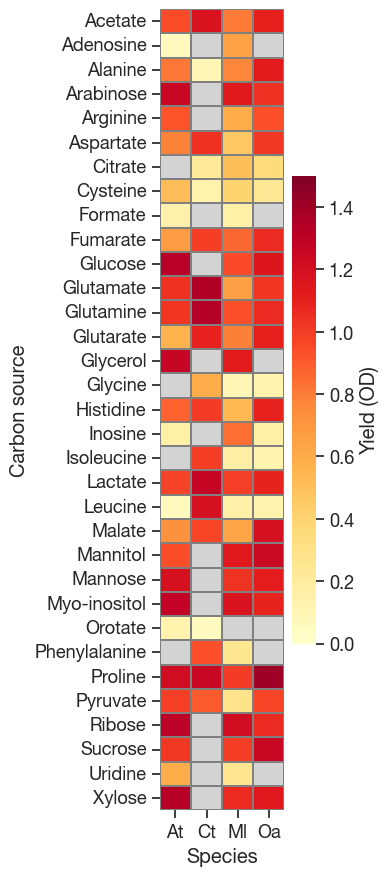

In [175]:
fig, ax = plt.subplots(1, figsize=(4,9))
sns.heatmap(yield_matrix.loc[carbon_sources, species], vmin = 0, vmax = 1.5, 
            cmap = cmap, mask = mask, cbar_kws={'label': 'Yield (OD)'}, ax = ax, linewidths=0.1, linecolor='gray')
plt.tight_layout()
plt.savefig('../../Supplementary_figures/heatmap_yield.pdf')

## Growth rate

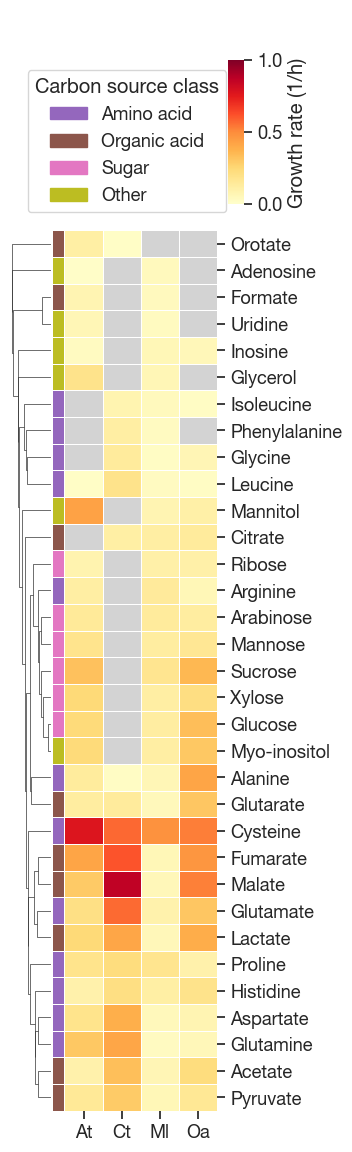

In [176]:
cmap = plt.colormaps.get_cmap('YlOrRd')
cmap.set_bad("lightgray")

mu_matrix = res_df[['Carbon source', 'max_growth_rate', 'Species']].pivot(index = 'Carbon source', columns='Species', values='max_growth_rate')
mask = np.zeros(mu_matrix.shape, dtype=bool)
for i, c in enumerate(mu_matrix.index):
    for j, s in enumerate(mu_matrix.columns):
        mask[i,j] = not binary_growth_dict[s][c]
mu_matrix.fillna(0, inplace=True)
g = sns.clustermap(mu_matrix, vmin = 0, vmax = 1, cmap = cmap, mask = mask,figsize=(4,12),
                dendrogram_ratio=0.2, cbar_kws={'label': 'Growth rate (1/h)'},
                cbar_pos=(0.6, 0.82, 0.04, 0.12),
                row_colors=row_colors,
                col_cluster=False,
                method='single',
                metric='braycurtis',
                colors_ratio=0.06,
                linewidths=0.7, linecolor='w')

# Create legend handles
handles = [
    mpatches.Patch(color=color, label=cls)
    for cls, color in class_to_color.items()
]

# Add legend to the clustermap
g.ax_heatmap.legend(
    handles=handles,
    title="Carbon source class",
    loc="lower left",
    bbox_to_anchor=(-0.3, 1.01)
)


g.ax_heatmap.set_ylabel('')
g.ax_heatmap.set_xlabel('')
fn_fig = figure_folder / 'clustermap_rate.pdf'

plt.savefig(fn_fig)

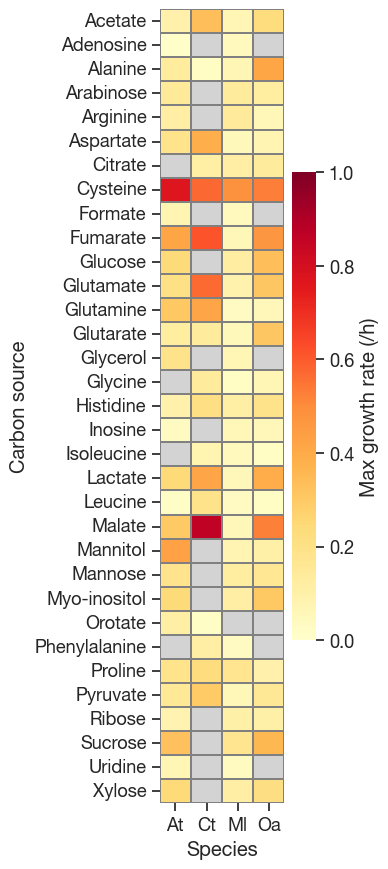

In [177]:
fig, ax = plt.subplots(1, figsize=(4,9))
sns.heatmap(mu_matrix.loc[carbon_sources, species], vmin = 0, vmax = 1, cmap = cmap, mask = mask, cbar_kws={'label': 'Max growth rate (/h)'}, ax = ax, linewidths=0.1, linecolor='gray')
plt.tight_layout()
plt.savefig('../../Supplementary_figures/heatmap_growth_rate.pdf')

# Plot distributions

In [178]:
res_df[['Carbon source', 'max_growth_rate', 'Species']]

,Carbon source,max_growth_rate,Species
0,Acetate,0.095601,At
1,Adenosine,0.013572,At
2,Alanine,0.133138,At
3,Arabinose,0.144967,At
4,Arginine,0.119682,At
...,...,...,...
130,Pyruvate,0.156408,Oa
131,Ribose,0.103032,Oa
132,Sucrose,0.356051,Oa
133,Uridine,NaN,Oa


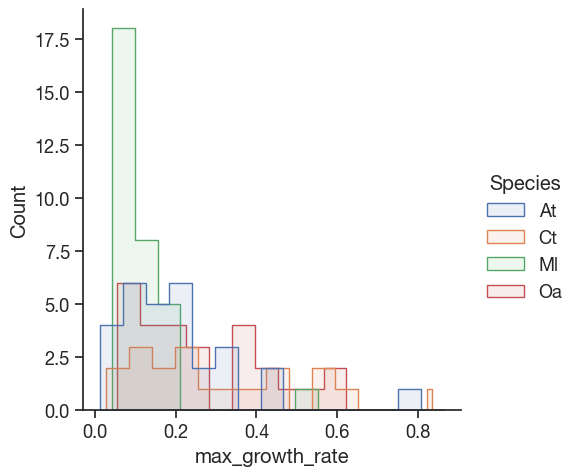

In [179]:
# mu_matrix
sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = False, multiple="dodge", bins = 15, element="step", fill=True, alpha = 0.1)
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = False, multiple="dodge", bins = 15, element="step", fill=True)

# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


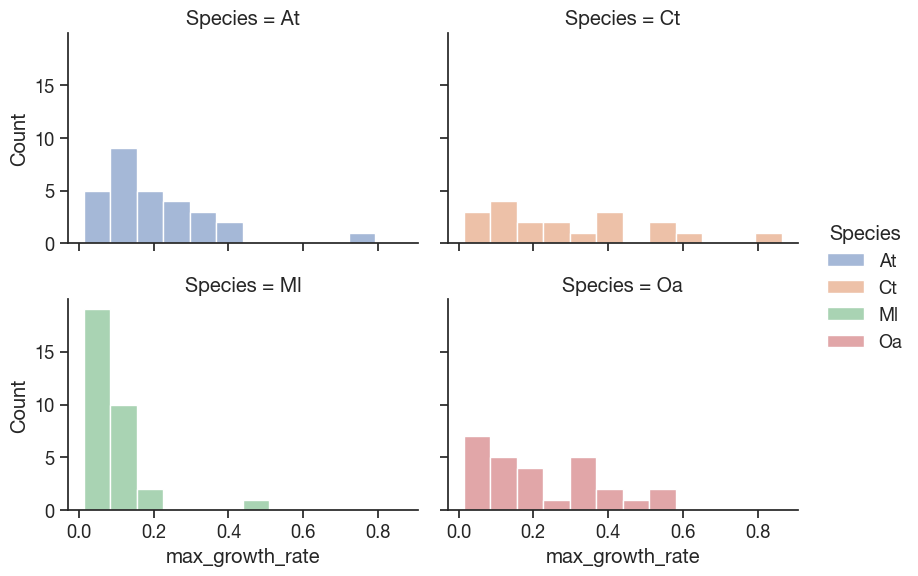

In [180]:
# mu_matrix
sns.displot(data = res_df, x = 'max_growth_rate', col = 'Species', kde = False, col_wrap=2, hue = 'Species', aspect=1.4, height=3, stat = 'count')# element="step", fill=True, alpha = 0.1
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


In [181]:
res_df.columns

Index(['Species', 'Carbon source', 'model', 'RSS', 'RMSD', 'bic', 'aic',
       'weighted_bic', 'weighted_aic', 'y0', 'K', 'r', 'nu', 'q0', 'v',
       'has_lag', 'has_nu', 'max_growth_rate', 'min_doubling_time', 'lag',
       'Binary growth evaluation', 'Yield'],
      dtype='object')

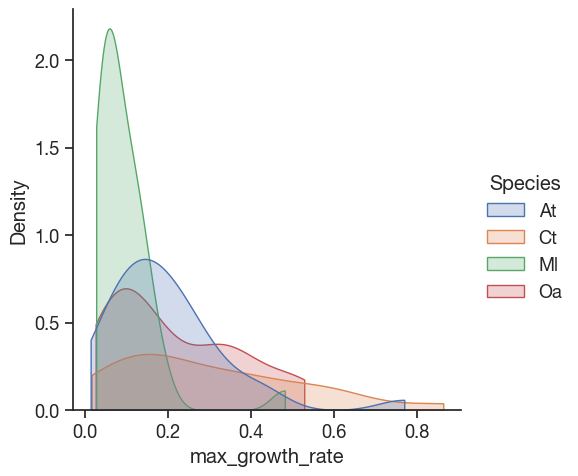

In [182]:
# mu_matrix
sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', hue = 'Species', kind = 'kde', bw_adjust = 0.8, common_norm = True, fill = True, cut = 0)
# sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', hue = 'Species', kind = 'kde', bw_adjust = 0.8)
# plt.xlim(0, 1.5)
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


In [183]:
res_df.columns

Index(['Species', 'Carbon source', 'model', 'RSS', 'RMSD', 'bic', 'aic',
       'weighted_bic', 'weighted_aic', 'y0', 'K', 'r', 'nu', 'q0', 'v',
       'has_lag', 'has_nu', 'max_growth_rate', 'min_doubling_time', 'lag',
       'Binary growth evaluation', 'Yield'],
      dtype='object')

In [184]:
versatility = res_df.groupby('Species')['Binary growth evaluation'].sum()/res_df['Carbon source'].nunique()



In [185]:
data = res_df.loc[res_df['Binary growth evaluation'] == True,'max_growth_rate']
fit_alpha, fit_loc, fit_beta=stats.gamma.fit(data)

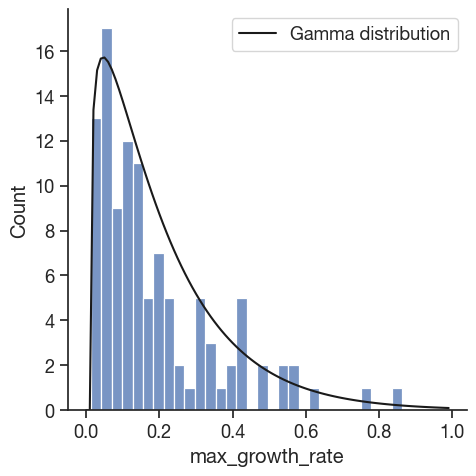

In [186]:
# mu_matrix
g = sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', kind = 'hist', common_norm = True, fill = True, bins = 30)
# sns.displot(data = res_df.loc[res_df['Binary growth evaluation'] == True,:], x = 'max_growth_rate', hue = 'Species', kind = 'kde', bw_adjust = 0.8)
# plt.xlim(0, 1.5)
# sns.displot(data = res_df, x = 'max_growth_rate', hue = 'Species', kde = 'True', multiple="stack", element="poly")


x = np.arange(0,1,0.01)
# fit_loc = 0.013
# # fit_beta = 1
fit_alpha = 1.2
y1 = stats.gamma.pdf(x, fit_alpha, fit_loc, fit_beta)
g.ax.plot(x, y1*4, c = 'k', label = 'Gamma distribution')
sns.despine()
plt.legend()

# Fraction of non-utizeable CS

In [187]:
fraction_ofU = res_df.groupby('Species').agg({'Binary growth evaluation': 'sum'})/33

In [188]:
max_g = res_df.groupby('Species').agg({'max_growth_rate': ['mean', 'std']})

Text(0, 0.5, 'Max growth rate')

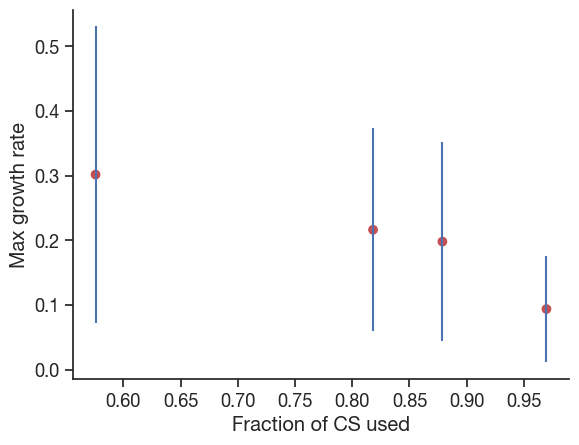

In [189]:
plt.scatter(fraction_ofU['Binary growth evaluation'], max_g['max_growth_rate']['mean'], c = ['r', 'r', 'r', 'r'])#, yerr=max_g['max_growth_rate']['std'], fmt = ''
plt.errorbar(fraction_ofU['Binary growth evaluation'], max_g['max_growth_rate']['mean'], yerr=max_g['max_growth_rate']['std'], fmt='', linestyle='')
sns.despine()
plt.xlabel('Fraction of CS used')
plt.ylabel('Max growth rate')
# l0, = plt.plot(x,y, marker='o', color='b')
# eb = plt.errorbar(x, y, yerr=.1, fmt=None, color='b')

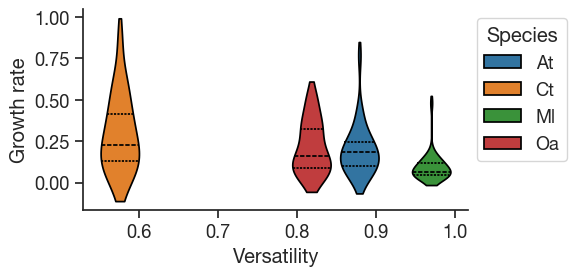

In [194]:


# Prepare data: merge fraction_ofU and res_df
res_df['fraction_ofU'] = res_df['Species'].map(fraction_ofU['Binary growth evaluation'])

fig, ax = plt.subplots(figsize=(6, 3))

# Show all data points (distribution) for each species at their fraction_ofU
sns.violinplot(
    data=res_df,
    x='fraction_ofU',
    y='max_growth_rate',
    hue='Species',
    # dodge=False,
    # jitter=True,
    # alpha=0.7,
    # inner = 'stick',
    inner = 'quartile',
    edgecolor='black',
    cut = True,
    palette = 'tab10',
    # split = True,
    # clip = True,
    native_scale=True,
    ax=ax
)

# # Optionally overlay a boxplot for summary
# sns.boxplot(
#     data=res_df,
#     x='fraction_ofU',
#     y='max_growth_rate',
#     showcaps=False,
#     boxprops={'facecolor':'None'},
#     showfliers=False,
#     whiskerprops={'linewidth':0},
#     ax=ax
# )

sns.despine()
ax.set_xlabel('Versatility')
ax.set_ylabel('Growth rate')
plt.legend(title='Species', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig(figure_folder / 'violinplot_growth_rate_vs_versatility.pdf')
plt.show()

# Correlations

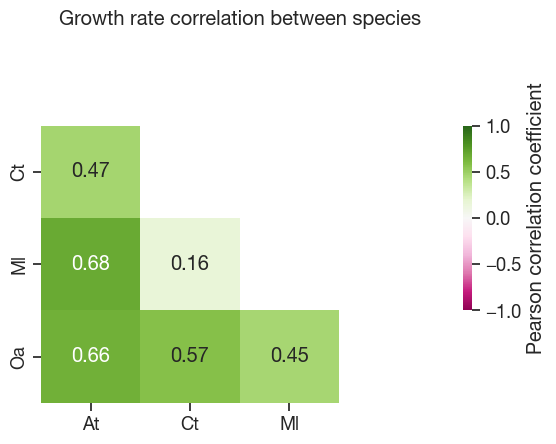

In [231]:
ax = sns.heatmap(mu_matrix.corr(), mask = np.triu(np.ones_like(yield_matrix.corr(), dtype=bool), 0), cmap = 'PiYG', center = 0, vmin = -1, vmax = 1, 
            annot = True,
            cbar_kws={'label': 'Pearson correlation coefficient', 'shrink': 0.5})
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('Growth rate correlation between species')

# Remove the extra ticklables
ax.set_xticks(ax.get_xticks()[:-1])
ax.set_yticks(ax.get_yticks()[1:])
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')




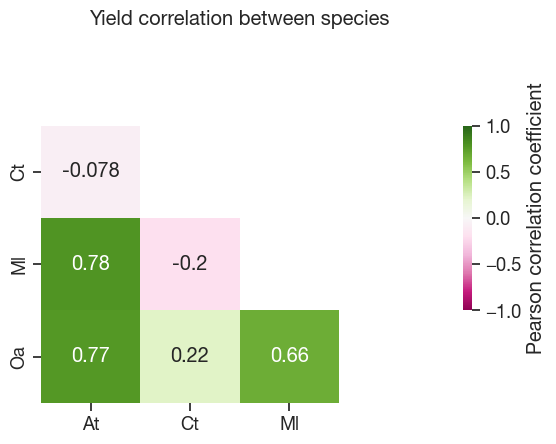

In [225]:
ax = sns.heatmap(yield_matrix.corr(), mask = np.triu(np.ones_like(yield_matrix.corr(), dtype=bool), 0), cmap = 'PiYG', center = 0, vmin = -1, vmax = 1, 
            annot = True,
            cbar_kws={'label': 'Pearson correlation coefficient', 'shrink': 0.5})
ax.set_ylabel('')
ax.set_xlabel('')
ax.set_title('Yield correlation between species')

# Remove the extra ticklables
ax.set_xticks(ax.get_xticks()[:-1])
ax.set_yticks(ax.get_yticks()[1:])
# ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment='right')


